# Marketing Analytics: Reservations Forecasting & Customer Segmentation

## 1. Introduction

### Business context
**Eventzella** is a platform connecting beneficiaries (clients) with event services. Marketing and operations need reliable visibility into **daily reservation volume** and a clear view of **who customers are** (value, activity, risk of churn) so budgets and campaigns can be allocated deliberately rather than reactively.

### Problem statement
- **Planning gap:** Campaign pacing, staffing, and inventory are weaker when leadership cannot anticipate near-term reservation demand.
- **Targeting gap:** Treating all beneficiaries alike wastes spend (high **CPA** on low-intent segments) and under-invests in retention for high-value relationships (**low retention** risk when outreach is mistimed).

### Machine learning objectives
1. **Predictive:** Build and compare time series models (**ARIMA**, **SARIMA** with weekly seasonality, **LSTM**) to forecast daily reservations.
2. **Prescriptive (segmentation):** Engineer **RFM** features and apply **K-Means** ($k=4$) to prioritize segments for differentiated marketing actions.

This notebook moves from **descriptive** summaries → **predictive** forecasts → **prescriptive** targeting recommendations.

## 2. Data loading

**Sheets used for the core fact table:**
- **`RESERVATION`:** transaction-level reservations (`id_reservation`, `reservation_date`, `final_price`, links to `id_event`).
- **`EVENT`:** event metadata including **`id_beneficiary`** (customer key).
- **`BENEFICIARY`:** customer attributes (profile enrichment / QA).

Optional sheets (e.g. `VISITORS`, `MARKETING_SPEND`) can support extended BI, but the ML pipeline below builds from reservations + events + beneficiaries.

**Environment:** Install into **this notebook’s kernel** (it may differ from Terminal’s Python). Run the next cell once. **LSTM:** the notebook tries **TensorFlow/Keras** first; if Windows reports a DLL error on `import tensorflow`, it falls back to **PyTorch**—install at least `torch` for that path (`%pip install torch`).


In [1]:
%pip install -q statsmodels openpyxl torch


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RNG = np.random.default_rng(42)
pd.options.display.max_columns = 30

for candidate in ("eventzella.xlsx", "eventzella_schema.xlsx"):
    p = Path.cwd() / candidate
    if p.exists():
        EXCEL_PATH = p
        break
else:
    raise FileNotFoundError(
        "Place eventzella.xlsx or eventzella_schema.xlsx in the same folder as this notebook."
    )

xl = pd.ExcelFile(EXCEL_PATH)
print("Workbook:", EXCEL_PATH.resolve())
print("Sheets:", xl.sheet_names)

required_sheets = {"RESERVATION", "EVENT", "BENEFICIARY"}
missing = required_sheets - set(xl.sheet_names)
if missing:
    raise ValueError(f"Workbook missing required sheet(s): {sorted(missing)}")

df_reservation = pd.read_excel(xl, sheet_name="RESERVATION")
df_event = pd.read_excel(xl, sheet_name="EVENT")
df_beneficiary = pd.read_excel(xl, sheet_name="BENEFICIARY")

print("\n--- RESERVATION (head) ---")
display(df_reservation.head())
print("\n--- RESERVATION (info) ---")
df_reservation.info()
print("\n--- RESERVATION (describe) ---")
display(df_reservation.describe(include="all").T)

print("\n--- EVENT (head) ---")
display(df_event.head())
df_event.info()

print("\n--- BENEFICIARY (head) ---")
display(df_beneficiary.head())
df_beneficiary.info()

Workbook: C:\Users\21658\Desktop\hazem\eventzella_schema.xlsx
Sheets: ['BENEFICIARY', 'PROVIDER', 'CATEGORY', 'SUBCATEGORY', 'SERVICE', 'EVENT', 'RESERVATION', 'EVALUATION', 'COMPLAINT', 'VISITORS', 'MARKETING_SPEND']

--- RESERVATION (head) ---


,id_reservation,id_service,id_event,reservation_date,status,final_price
0,1,819,6879,2025-07-15,pending,1454
1,2,575,6547,2023-03-31,pending,9070
2,3,2059,4505,2025-11-18,confirmed,5025
3,4,614,986,2022-01-04,pending,10116
4,5,361,3677,2024-02-01,confirmed,6971



--- RESERVATION (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_reservation    18000 non-null  int64         
 1   id_service        18000 non-null  int64         
 2   id_event          18000 non-null  int64         
 3   reservation_date  18000 non-null  datetime64[ns]
 4   status            18000 non-null  object        
 5   final_price       18000 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 843.9+ KB

--- RESERVATION (describe) ---


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_reservation,18000.0,NaN,NaN,NaN,9000.5,1.0,4500.75,9000.5,13500.25,18000.0,5196.296758
id_service,18000.0,NaN,NaN,NaN,1251.273833,1.0,626.75,1242.0,1882.0,2500.0,723.674157
id_event,18000.0,NaN,NaN,NaN,5975.988556,1.0,2982.75,5943.0,8999.25,12000.0,3459.186411
reservation_date,18000,NaN,NaN,NaN,2023-12-29 21:25:12,2022-01-01 00:00:00,2022-12-30 00:00:00,2023-12-27 00:00:00,2024-12-28 00:00:00,2025-12-31 00:00:00,NaN
status,18000,3,confirmed,6024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
final_price,18000.0,NaN,NaN,NaN,9838.8035,201.0,3970.0,7799.5,11630.5,149610.0,15144.614496



--- EVENT (head) ---


,id_event,title,event_date,budget,type,id_beneficiary
0,1,Whether require bank.,2025-05-29,46238.0,Birthday,2596
1,2,Environmental decide talk.,2022-05-16,42004.0,Private Party,3560
2,3,Of believe.,2023-05-15,379020.0,Wedding,4683
3,4,Theory middle.,2023-01-03,49114.0,Birthday,4372
4,5,And reality heart.,2025-07-24,10776.0,Private Party,834


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_event        12000 non-null  int64         
 1   title           12000 non-null  object        
 2   event_date      12000 non-null  datetime64[ns]
 3   budget          11052 non-null  float64       
 4   type            12000 non-null  object        
 5   id_beneficiary  12000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 562.6+ KB

--- BENEFICIARY (head) ---


,id_beneficiary,first_name,last_name,email,phone
0,1,Derek,Lara,NaN,(501)218-4139
1,2,Lori,Wu,heatherlopez@example.com,(370)559-8737
2,3,Holly,Haas,xsanders@example.net,(758)955-2220x8114
3,4,Joshua,NaN,tmoran@example.org,001-719-729-2982
4,5,Dennis,NaN,faulknernicole@example.org,(782)479-0070


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_beneficiary  5000 non-null   int64 
 1   first_name      5000 non-null   object
 2   last_name       4652 non-null   object
 3   email           4600 non-null   object
 4   phone           4611 non-null   object
dtypes: int64(1), object(4)
memory usage: 195.4+ KB


### Brief dataset explanations
- **`RESERVATION`:** Grain = one reservation line. Carries **`reservation_date`** (when the booking was made) and **`final_price`** (monetary outcome for segmentation).
- **`EVENT`:** Grain = one event. Bridges reservations to the owning customer via **`id_beneficiary`**.
- **`BENEFICIARY`:** Grain = one customer identity; useful for validating customer coverage and optional profile context.

**Note:** Original specs referenced surrogate keys like `date_sk` / `beneficiary_sk`. In this workbook, **`id_beneficiary`** is the beneficiary key and calendar attributes are derived from **`reservation_date`** (see next section).

In [3]:
# Column presence checks (fail fast if schema drifts)
def require_columns(df, cols, name):
    bad = [c for c in cols if c not in df.columns]
    if bad:
        raise ValueError(f"{name} missing column(s): {bad}")

require_columns(df_reservation, ["id_reservation", "id_event", "reservation_date", "final_price"], "RESERVATION")
require_columns(df_event, ["id_event", "id_beneficiary"], "EVENT")
require_columns(df_beneficiary, ["id_beneficiary"], "BENEFICIARY")

# Datetime conversion
df_reservation = df_reservation.copy()
df_event = df_event.copy()
df_beneficiary = df_beneficiary.copy()

df_reservation["reservation_date"] = pd.to_datetime(df_reservation["reservation_date"], errors="coerce")
if df_event["event_date"].dtype == "object":
    df_event["event_date"] = pd.to_datetime(df_event["event_date"], errors="coerce")

# Merge to attach beneficiary to each reservation
df_fact = df_reservation.merge(
    df_event[["id_event", "id_beneficiary"]],
    on="id_event",
    how="left",
    validate="m:1",
)

df_fact.rename(columns={"final_price": "price", "id_beneficiary": "beneficiary_sk"}, inplace=True)

# Missing value audit
na_rate = df_fact.isna().mean().sort_values(ascending=False)
print("Top NA rates (fact):")
display(na_rate.head(10))

# Rules: drop reservations with unknown date or unknown beneficiary (cannot attribute or time-order)
before = len(df_fact)
df_fact = df_fact.dropna(subset=["reservation_date", "beneficiary_sk"])
after = len(df_fact)
print(f"Dropped {before - after} rows with missing reservation_date or beneficiary_sk.")

# price: for segmentation we need numeric price; fill remaining NA with 0 only if any exist
if df_fact["price"].isna().any():
    n = int(df_fact["price"].isna().sum())
    print(f"Warning: filling {n} missing price with 0 for aggregation (investigate upstream).")
    df_fact["price"] = df_fact["price"].fillna(0)
else:
    print("No missing price values after merge.")

# dim_date from observed calendar days
min_d = df_fact["reservation_date"].min().normalize()
max_d = df_fact["reservation_date"].max().normalize()
dim_date = pd.DataFrame({"full_date": pd.date_range(min_d, max_d, freq="D")})
dim_date["date_sk"] = (dim_date["full_date"] - dim_date["full_date"].min()).dt.days.astype(int)

# Attach date_sk to fact (calendar day of reservation)
df_fact["full_date"] = df_fact["reservation_date"].dt.normalize()
df_fact = df_fact.merge(dim_date[["full_date", "date_sk"]], on="full_date", how="left")

display(df_fact.head())
print(df_fact[["id_reservation", "beneficiary_sk", "date_sk", "price", "full_date"]].info())

Top NA rates (fact):


id_reservation      0.0
id_service          0.0
id_event            0.0
reservation_date    0.0
status              0.0
price               0.0
beneficiary_sk      0.0
dtype: float64

Dropped 0 rows with missing reservation_date or beneficiary_sk.
No missing price values after merge.


,id_reservation,id_service,id_event,reservation_date,status,price,beneficiary_sk,full_date,date_sk
0,1,819,6879,2025-07-15,pending,1454,2997,2025-07-15,1291
1,2,575,6547,2023-03-31,pending,9070,3028,2023-03-31,454
2,3,2059,4505,2025-11-18,confirmed,5025,4754,2025-11-18,1417
3,4,614,986,2022-01-04,pending,10116,2074,2022-01-04,3
4,5,361,3677,2024-02-01,confirmed,6971,1399,2024-02-01,761


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_reservation  18000 non-null  int64         
 1   beneficiary_sk  18000 non-null  int64         
 2   date_sk         18000 non-null  int64         
 3   price           18000 non-null  int64         
 4   full_date       18000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(4)
memory usage: 703.2 KB
None


## 4. Time series preparation

We model **daily reservation counts** (volume), a standard operations/marketing KPI. Steps:
1. Aggregate **`id_reservation`** count per calendar day.
2. Reindex to a **continuous daily** timeline between min and max dates.
3. **Fill missing days with 0** (no reservations recorded).
4. Plot the series for visual diagnostics (trend + noise; weekly seasonality is plausible for event businesses).

**Visuals in the next cell:** (1) raw daily counts with a **30-day rolling mean** to highlight smooth trend vs noise; (2) a **histogram** of daily volumes (typical range and skew); (3) **boxplots by weekday** to see intra-week seasonality; (4) **monthly totals** to show longer business cycles.


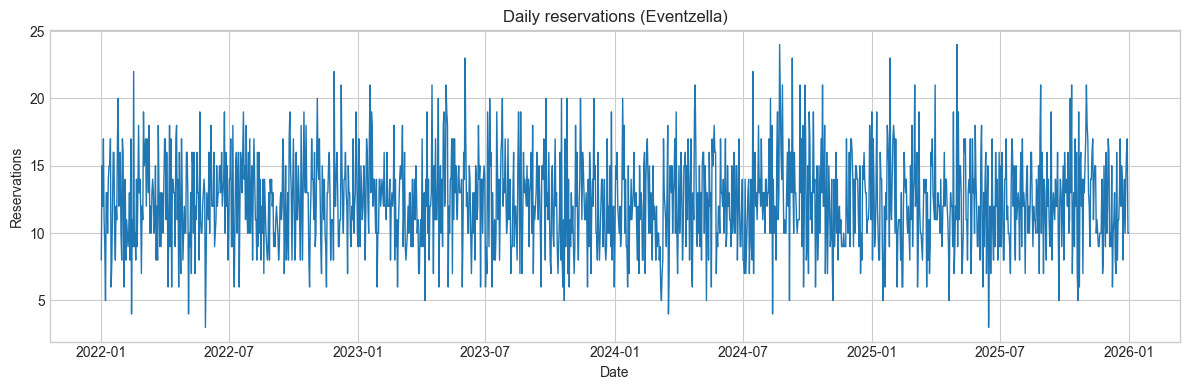

Days: 1461 | mean daily reservations: 12.320328542094456


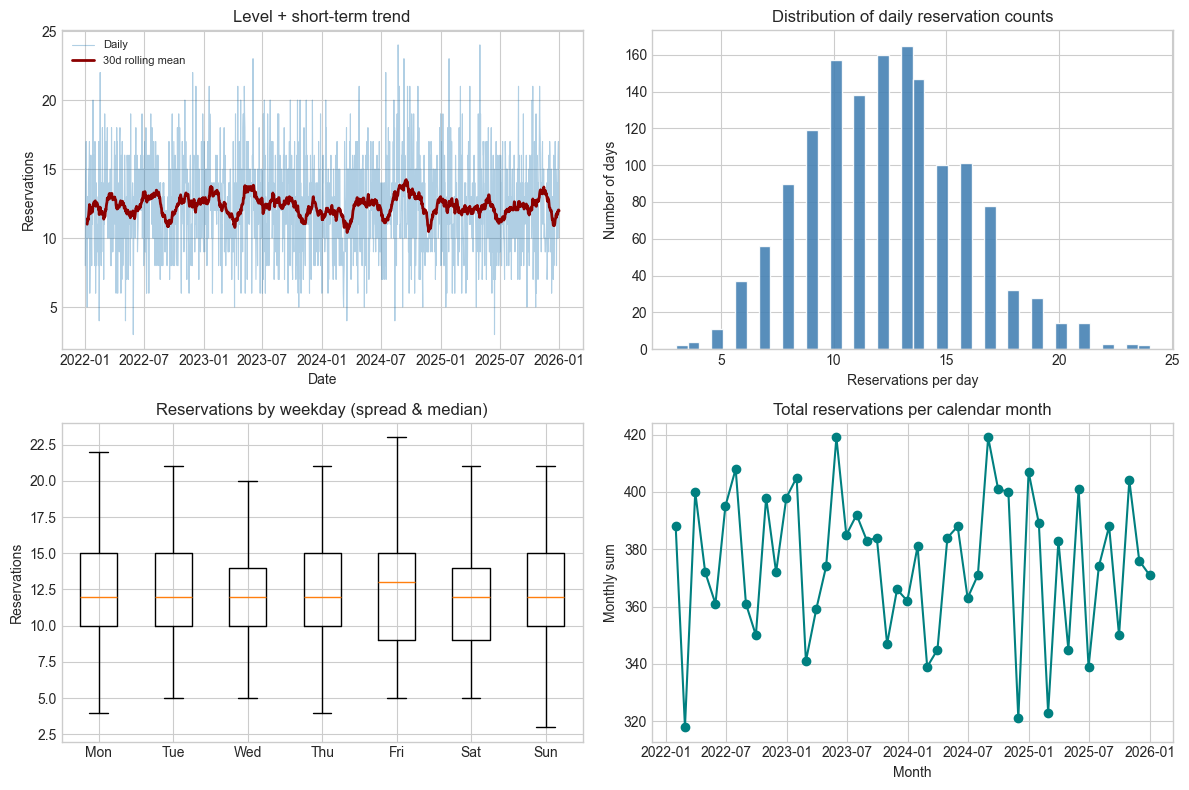

In [4]:
daily = (
    df_fact.groupby("full_date", as_index=False)
    .agg(reservations=("id_reservation", "count"), revenue=("price", "sum"))
    .sort_values("full_date")
)

full_idx = pd.date_range(daily["full_date"].min(), daily["full_date"].max(), freq="D")
daily = daily.set_index("full_date").reindex(full_idx)
daily.index.name = "full_date"
daily["reservations"] = daily["reservations"].fillna(0)
daily["revenue"] = daily["revenue"].fillna(0)
daily = daily.reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["full_date"], daily["reservations"], color="#1f77b4", linewidth=1)
ax.set_title("Daily reservations (Eventzella)")
ax.set_xlabel("Date")
ax.set_ylabel("Reservations")
plt.tight_layout()
plt.show()

y = daily["reservations"].astype(float).values
dates = daily["full_date"]
print("Days:", len(daily), "| mean daily reservations:", float(np.mean(y)))

# --- Additional descriptive visuals ---
daily["weekday_num"] = daily["full_date"].dt.dayofweek
wd_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.plot(daily["full_date"], daily["reservations"], alpha=0.35, label="Daily", color="#1f77b4", linewidth=0.8)
roll = daily["reservations"].rolling(30, min_periods=7).mean()
ax.plot(daily["full_date"], roll, color="darkred", linewidth=2, label="30d rolling mean")
ax.set_title("Level + short-term trend")
ax.legend(loc="upper left", fontsize=8)
ax.set_xlabel("Date")
ax.set_ylabel("Reservations")

ax = axes[0, 1]
ax.hist(daily["reservations"], bins=40, color="steelblue", edgecolor="white", alpha=0.9)
ax.set_title("Distribution of daily reservation counts")
ax.set_xlabel("Reservations per day")
ax.set_ylabel("Number of days")

ax = axes[1, 0]
data_by_dow = [daily.loc[daily["weekday_num"] == d, "reservations"].values for d in range(7)]
ax.boxplot(data_by_dow, tick_labels=wd_labels, showfliers=False)
ax.set_title("Reservations by weekday (spread & median)")
ax.set_ylabel("Reservations")

ax = axes[1, 1]
m_sum = daily.set_index("full_date")["reservations"].resample("ME").sum().reset_index()
ax.plot(m_sum["full_date"], m_sum["reservations"], marker="o", color="teal", linewidth=1.5)
ax.set_title("Total reservations per calendar month")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly sum")

plt.tight_layout()
plt.show()



### Reading the descriptive charts

- **Daily + 30-day rolling mean:** The thin blue line is noisy day-to-day demand; the red curve smooths that noise. When the red line climbs or falls, it signals a **sustained** shift (campaign effect, season, or data quality), not a one-off spike.
- **Histogram:** Shows how often the business sees "low," "typical," or "high" volume days. A long right tail means occasional **peak days** (good for capacity planning).
- **Weekday boxplots:** Compare medians and spread across Mon–Sun. Clear separation suggests **strong weekly seasonality** (motivation for SARIMA with $m=7$).
- **Monthly totals:** Long-horizon **growth or decline** in activity; useful context when judging whether forecast errors are larger in high-volume months.


## 5. Forecasting models

We hold out the **last 90 days** as a test window and train on all prior days.

### A. ARIMA
A compact autoregressive integrated moving-average benchmark.

### B. SARIMA (weekly seasonality)
We set seasonal period **`m = 7`** to capture day-of-week effects common in bookings.

### C. LSTM (TensorFlow / Keras, with PyTorch fallback)
We **normalize** with `MinMaxScaler` fit on the **training** split only, use sliding windows (**lookback = 14**), and train a small **LSTM → dense** model. Test predictions are **recursive** (multi-step), like the classical baselines.

The implementation **tries TensorFlow/Keras first**. If Windows raises a **DLL / TensorFlow Lite** error on import, it **falls back to PyTorch** automatically (install `torch` via the setup cell).

In [5]:
TEST_H = 90
train = y[:-TEST_H]
test = y[-TEST_H:]
print("Train length:", len(train), "| Test length:", len(test))

Train length: 1371 | Test length: 90


In [6]:
# --- ARIMA ---
from statsmodels.tsa.arima.model import ARIMA

arima_order = (2, 1, 2)
arima_model = ARIMA(train, order=arima_order).fit()
arima_pred = arima_model.forecast(steps=len(test))

In [7]:
# --- SARIMA (weekly seasonality) ---
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
sarima_pred = sarima_model.forecast(steps=len(test))

In [8]:
# --- LSTM: TensorFlow/Keras first; PyTorch fallback (common Windows TF DLL issue) ---
lookback = 14


def make_xy(series, lb, start, end):
    xs, ys = [], []
    for i in range(start, end):
        xs.append(series[i - lb : i])
        ys.append(series[i])
    return np.array(xs), np.array(ys)


scaler = MinMaxScaler()
train_s = scaler.fit_transform(train.reshape(-1, 1)).flatten()
full_s = scaler.transform(y.reshape(-1, 1)).flatten()

tr_start = lookback
tr_end = len(train)
X_tr, y_tr = make_xy(full_s, lookback, tr_start, tr_end)
X_tr = X_tr.reshape(-1, lookback, 1)

lstm_scaled_preds = []
lstm_backend = None

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    tf.random.set_seed(42)
    keras_model = keras.Sequential(
        [
            layers.Input(shape=(lookback, 1)),
            layers.LSTM(32, dropout=0.1),
            layers.Dense(1),
        ]
    )
    keras_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    es = keras.callbacks.EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)
    keras_model.fit(X_tr, y_tr, epochs=80, batch_size=32, verbose=0, callbacks=[es])

    start_idx = len(train)
    window = full_s[start_idx - lookback : start_idx].copy()
    for _ in range(len(test)):
        x = window.reshape(1, lookback, 1)
        p = float(keras_model.predict(x, verbose=0)[0, 0])
        lstm_scaled_preds.append(p)
        window = np.append(window[1:], p)

    lstm_backend = "tensorflow"

except Exception as tf_err:
    import torch
    import torch.nn as nn

    msg = str(tf_err)
    if len(msg) > 140:
        msg = msg[:140] + "..."
    print(f"TensorFlow/Keras unavailable ({type(tf_err).__name__}: {msg})")
    print("Using PyTorch for the LSTM instead.")

    class _DailyLSTM(nn.Module):
        def __init__(self, lb):
            super().__init__()
            self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
            self.dropout = nn.Dropout(0.1)
            self.fc = nn.Linear(32, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(self.dropout(out[:, -1, :]))

    torch.manual_seed(42)
    X_t = torch.from_numpy(X_tr.astype(np.float32))
    y_t = torch.from_numpy(y_tr.astype(np.float32).reshape(-1, 1))
    pt_model = _DailyLSTM(lookback)
    opt = torch.optim.Adam(pt_model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    pt_model.train()
    for _ in range(80):
        opt.zero_grad()
        loss = loss_fn(pt_model(X_t), y_t)
        loss.backward()
        opt.step()

    pt_model.eval()
    start_idx = len(train)
    window = full_s[start_idx - lookback : start_idx].copy()
    with torch.no_grad():
        for _ in range(len(test)):
            x = torch.from_numpy(window.reshape(1, lookback, 1).astype(np.float32))
            p = float(pt_model(x)[0, 0].numpy())
            lstm_scaled_preds.append(p)
            window = np.append(window[1:], p)

    lstm_backend = "pytorch"

lstm_pred = scaler.inverse_transform(np.array(lstm_scaled_preds).reshape(-1, 1)).flatten()
lstm_pred = np.clip(lstm_pred, 0, None)
print("LSTM backend used:", lstm_backend)

TensorFlow/Keras unavailable (ImportError: DLL load failed while importing _pywrap_tensorflow_lite_metrics_wrapper: The specified procedure could not be found.)
Using PyTorch for the LSTM instead.
LSTM backend used: pytorch


## 6. Model evaluation

We score each model on the **90-day test** window using several complementary metrics (all on the same recursive / multi-step protocol for LSTM):

| Metric | Meaning |
|--------|--------|
| **RMSE** | Penalises large misses; sensitive to outliers (good when big errors are costly). |
| **MAE** | Average absolute error in **same units** as reservations/day; easy to explain to stakeholders. |
| **MAPE (%)** | Percent error where actual demand $>0$; scale-free, but ignore days with zero actuals in the MAPE formula. |
| **sMAPE (%)** | Symmetric % error; more stable when counts are small. |
| **R²** | Share of variance explained (1 = perfect, 0 = no better than predicting the mean). |
| **MBE** | Mean(predicted − actual): **>0** means systematic **over-forecast**, **<0** means **under-forecast** (capacity vs marketing bias). |

**Primary choice for "best model"** here remains **lowest RMSE**, but we use the other metrics to sanity-check behaviour (e.g. low RMSE but bad MAPE can mean rare large errors vs systematic % miss). The plots below show **residuals over time**, **actual vs predicted**, and a **metric comparison** across models.


,rank,RMSE,MAE,MSE,MAPE_%,sMAPE_%,R2,MBE,model
0,1,3.547573,2.967595,12.585278,27.647909,24.487785,-0.000243,0.073199,LSTM
1,2,3.549585,2.962486,12.599555,27.122261,24.460229,-0.001378,-0.148736,SARIMA (m=7)
2,3,3.550209,2.963476,12.603982,27.109533,24.469079,-0.001729,-0.155611,ARIMA


Best model (lowest RMSE): LSTM


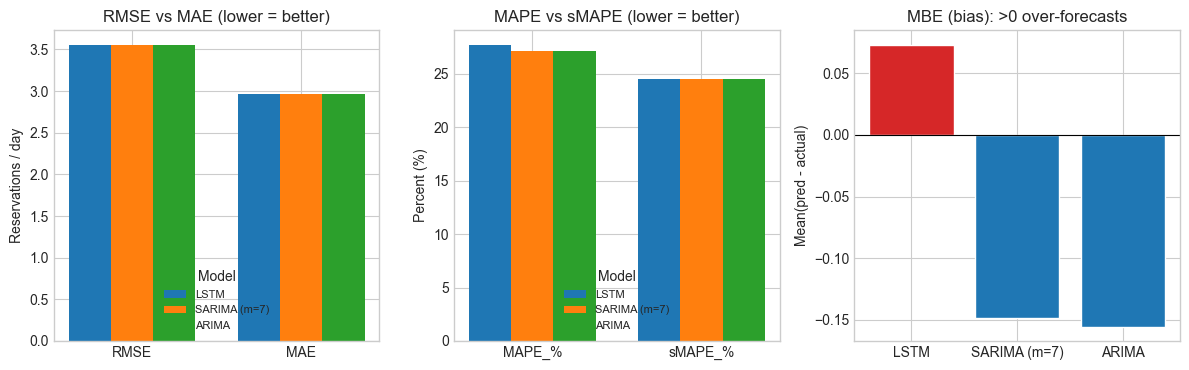

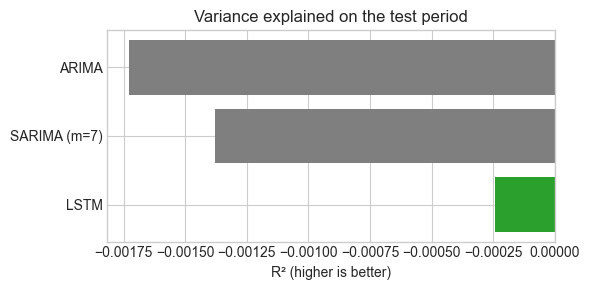

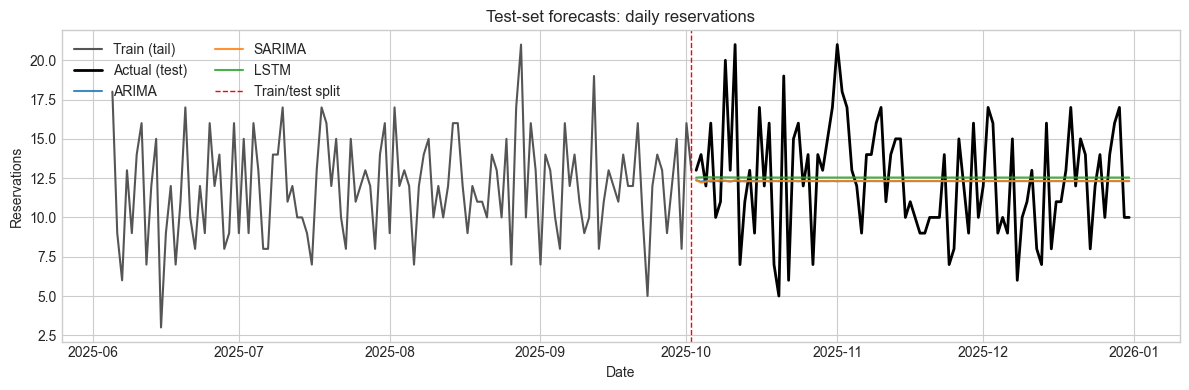

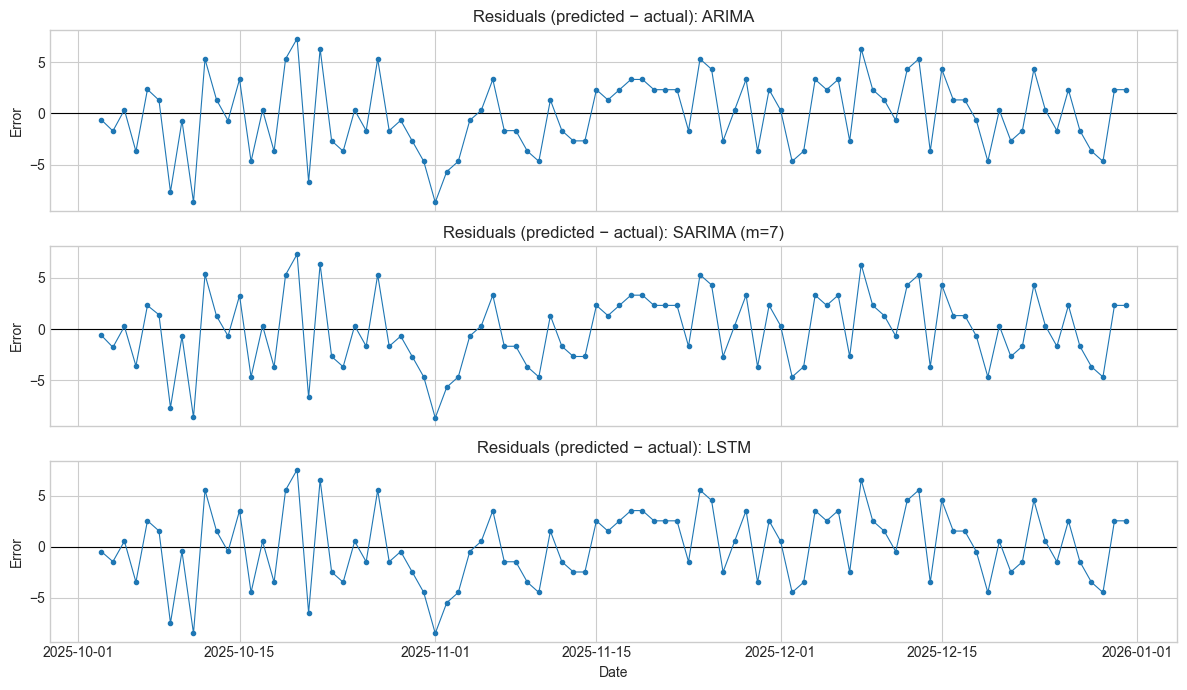

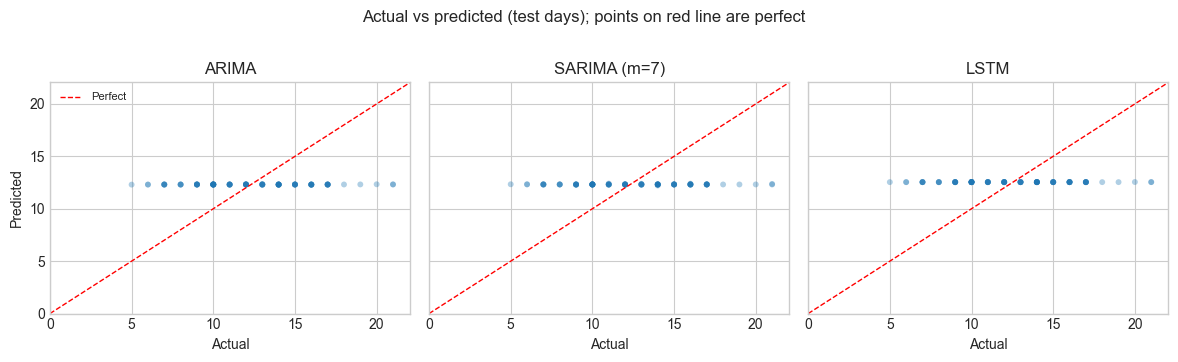

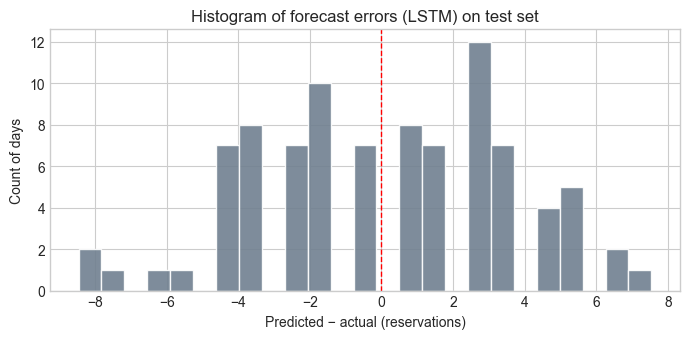

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse_v = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae_v = float(mean_absolute_error(y_true, y_pred))
    mse_v = float(mean_squared_error(y_true, y_pred))
    r2_v = float(r2_score(y_true, y_pred))
    mbe_v = float(np.mean(y_pred - y_true))
    mask = y_true > 0
    if mask.sum() > 0:
        mape_v = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)
    else:
        mape_v = float("nan")
    smape_v = float(np.mean(200.0 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)))
    return {
        "RMSE": rmse_v,
        "MAE": mae_v,
        "MSE": mse_v,
        "MAPE_%": mape_v,
        "sMAPE_%": smape_v,
        "R2": r2_v,
        "MBE": mbe_v,
    }


preds = {"ARIMA": arima_pred, "SARIMA (m=7)": sarima_pred, "LSTM": lstm_pred}
metric_rows = []
for name, p in preds.items():
    m = regression_metrics(test, p)
    m["model"] = name
    metric_rows.append(m)

eval_tbl = pd.DataFrame(metric_rows)
eval_tbl = eval_tbl.sort_values("RMSE").reset_index(drop=True)
eval_tbl.insert(0, "rank", np.arange(1, len(eval_tbl) + 1))
display(eval_tbl)

best_model = eval_tbl.loc[0, "model"]
print("Best model (lowest RMSE):", best_model)

last_train_date = dates.iloc[len(train) - 1]
test_dates = dates.iloc[len(train) : len(train) + len(test)]

# --- Metric comparison (separate scales: count errors vs % vs bias) ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
w = 0.25
units = eval_tbl.set_index("model")[["RMSE", "MAE"]].T
x0 = np.arange(len(units.index))
for i, model in enumerate(units.columns):
    axes[0].bar(x0 + i * w, units[model].values, width=w, label=model)
axes[0].set_xticks(x0 + w)
axes[0].set_xticklabels(units.index)
axes[0].set_ylabel("Reservations / day")
axes[0].set_title("RMSE vs MAE (lower = better)")
axes[0].legend(title="Model", fontsize=8)

pct = eval_tbl.set_index("model")[["MAPE_%", "sMAPE_%"]].T
x1 = np.arange(len(pct.index))
for i, model in enumerate(pct.columns):
    axes[1].bar(x1 + i * w, pct[model].values, width=w, label=model)
axes[1].set_xticks(x1 + w)
axes[1].set_xticklabels(pct.index)
axes[1].set_ylabel("Percent (%)")
axes[1].set_title("MAPE vs sMAPE (lower = better)")
axes[1].legend(title="Model", fontsize=8)

mbe = eval_tbl.set_index("model")["MBE"]
colors_mbe = ["#d62728" if v > 0 else "#1f77b4" for v in mbe.values]
axes[2].bar(mbe.index.astype(str), mbe.values, color=colors_mbe, edgecolor="white")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("MBE (bias): >0 over-forecasts")
axes[2].set_ylabel("Mean(pred - actual)")
plt.tight_layout()
plt.show()

# R² separate (higher better)
fig, ax = plt.subplots(figsize=(6, 3))
r2s = eval_tbl.set_index("model")["R2"].sort_values(ascending=False)
colors = ["#2ca02c" if m == best_model else "#7f7f7f" for m in r2s.index]
ax.barh(r2s.index.astype(str), r2s.values, color=colors)
ax.set_xlabel("R² (higher is better)")
ax.set_title("Variance explained on the test period")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Holdout: actual vs forecasts ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates.iloc[len(train) - 120 : len(train)], y[len(train) - 120 : len(train)], label="Train (tail)", color="#555")
ax.plot(test_dates, test, label="Actual (test)", color="black", linewidth=2)
ax.plot(test_dates, arima_pred, label="ARIMA", alpha=0.85)
ax.plot(test_dates, sarima_pred, label="SARIMA", alpha=0.85)
ax.plot(test_dates, lstm_pred, label="LSTM", alpha=0.85)
ax.axvline(last_train_date, color="red", linestyle="--", linewidth=1, label="Train/test split")
ax.set_title("Test-set forecasts: daily reservations")
ax.set_xlabel("Date")
ax.set_ylabel("Reservations")
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

# --- Residuals over test period ---
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, (name, p) in zip(axes, preds.items()):
    resid = p - test
    ax.axhline(0, color="black", linewidth=0.8)
    ax.plot(test_dates, resid, marker=".", linestyle="-", linewidth=0.8)
    ax.set_ylabel("Error")
    ax.set_title(f"Residuals (predicted − actual): {name}")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# --- Actual vs predicted scatter (test) ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
lims = [0, max(float(test.max()), float(max(arima_pred.max(), sarima_pred.max(), lstm_pred.max()))) * 1.05]
for ax, (name, p) in zip(axes, preds.items()):
    ax.scatter(test, p, alpha=0.35, s=18, edgecolors="none")
    ax.plot(lims, lims, "r--", linewidth=1, label="Perfect")
    ax.set_title(name)
    ax.set_xlabel("Actual")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
axes[0].set_ylabel("Predicted")
axes[0].legend(loc="upper left", fontsize=8)
plt.suptitle("Actual vs predicted (test days); points on red line are perfect", y=1.02)
plt.tight_layout()
plt.show()

# --- Error distribution for best model ---
best_pred = preds[best_model]
err = best_pred - test
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(err, bins=25, color="slategray", edgecolor="white", alpha=0.9)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title(f"Histogram of forecast errors ({best_model}) on test set")
ax.set_xlabel("Predicted − actual (reservations)")
ax.set_ylabel("Count of days")
plt.tight_layout()
plt.show()



### Interpreting the forecast diagnostics

- **Metric bar charts (RMSE/MAE, MAPE/sMAPE, MBE):** Left: errors in **same units** as daily reservations. Middle: **percentage** errors (scale-free). Right: **MBE** shows systematic **bias** (red = over-forecast). **MAE ≪ RMSE** on the left often means a few **bad days** drive RMSE. **R²** near 1 means the model tracks day-to-day variation; near 0 means it is only slightly better than predicting the historical average.
- **Holdout line chart:** Visual **phase and amplitude** fit. A model that lags spikes (shifted to the right of black) reacts slowly; one that systematically sits above/below actuals matches timing but has **level bias** (see MBE).
- **Residuals vs time:** Ideally residuals look like **random noise** around 0. **Clusters** of positive then negative errors suggest **missed seasonality** or structural breaks (promotions, product changes).
- **Actual vs predicted scatter:** Points should hug the red diagonal. **Vertical spread** away from the line is **magnitude error**; **curvature** (cloud bends) suggests **nonlinear** behaviour the linear models miss (where LSTM can help).
- **Error histogram (best model):** Centered on 0 is good. A long tail on one side matches **non-symmetric** loss (RMSE vs MAE story) and helps you explain risk ("we rarely miss high, but when we do it is large").


## 7. Future forecast (next 30 days)

We refit the **best model** on the **full** history (`y`) and forecast **30 days** ahead, then plot history + forecast for stakeholder communication.

The extra chart compares the **point forecast** to the **trailing 90-day mean**: if the orange line sits far above/below that benchmark, discuss whether that is a credible signal or model overshoot before committing budget.


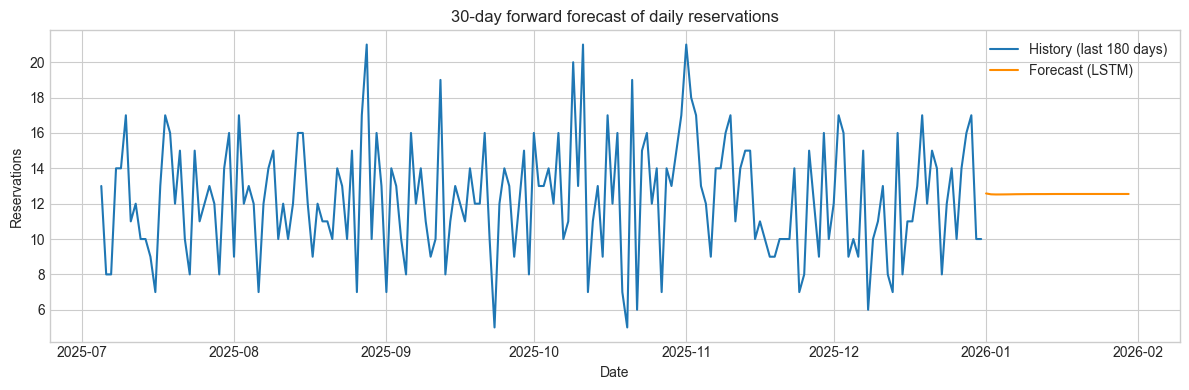

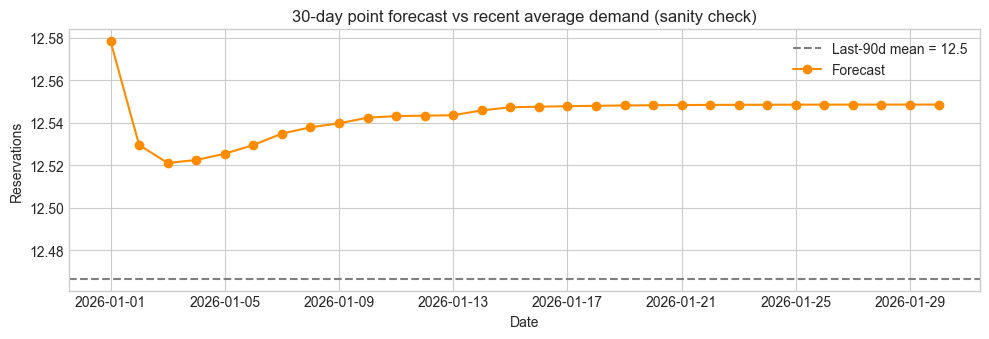

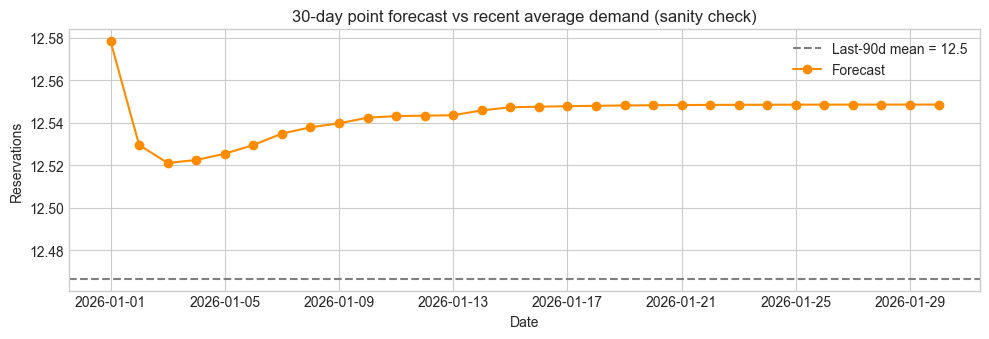

,date,forecast_reservations,model_used
0,2026-01-01,12.578331,LSTM
1,2026-01-02,12.529543,LSTM
2,2026-01-03,12.521104,LSTM
3,2026-01-04,12.522484,LSTM
4,2026-01-05,12.525457,LSTM


In [10]:
HORIZON = 30

if best_model.startswith("ARIMA"):
    future_model = ARIMA(y, order=arima_order).fit()
    y_future = future_model.forecast(steps=HORIZON)
elif best_model.startswith("SARIMA"):
    future_model = SARIMAX(
        y,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)
    y_future = future_model.forecast(steps=HORIZON)
elif str(best_model).startswith("LSTM"):
    if lstm_backend == "tensorflow":
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers

        tf.random.set_seed(42)
        scaler_f = MinMaxScaler()
        y_s = scaler_f.fit_transform(y.reshape(-1, 1)).flatten()
        Xf, yf = make_xy(y_s, lookback, lookback, len(y))
        Xf = Xf.reshape(-1, lookback, 1)
        fm = keras.Sequential(
            [
                layers.Input(shape=(lookback, 1)),
                layers.LSTM(32, dropout=0.1),
                layers.Dense(1),
            ]
        )
        fm.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
        es_f = keras.callbacks.EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)
        fm.fit(Xf, yf, epochs=80, batch_size=32, verbose=0, callbacks=[es_f])
        window = y_s[len(y) - lookback : len(y)].copy()
        future_scaled = []
        for _ in range(HORIZON):
            p = float(fm.predict(window.reshape(1, lookback, 1), verbose=0)[0, 0])
            future_scaled.append(p)
            window = np.append(window[1:], p)
        y_future = scaler_f.inverse_transform(np.array(future_scaled).reshape(-1, 1)).flatten()
        y_future = np.clip(y_future, 0, None)
    else:
        import torch
        import torch.nn as nn

        class _DailyLSTM(nn.Module):
            def __init__(self, lb):
                super().__init__()
                self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
                self.dropout = nn.Dropout(0.1)
                self.fc = nn.Linear(32, 1)

            def forward(self, x):
                out, _ = self.lstm(x)
                return self.fc(self.dropout(out[:, -1, :]))

        scaler_f = MinMaxScaler()
        y_s = scaler_f.fit_transform(y.reshape(-1, 1)).flatten()
        Xf, yf = make_xy(y_s, lookback, lookback, len(y))
        Xf_t = torch.from_numpy(Xf.reshape(-1, lookback, 1).astype(np.float32))
        yf_t = torch.from_numpy(yf.astype(np.float32).reshape(-1, 1))
        torch.manual_seed(42)
        fm = _DailyLSTM(lookback)
        opt = torch.optim.Adam(fm.parameters(), lr=1e-3)
        fm.train()
        for _ in range(80):
            opt.zero_grad()
            loss = nn.MSELoss()(fm(Xf_t), yf_t)
            loss.backward()
            opt.step()
        fm.eval()
        window = y_s[len(y) - lookback : len(y)].copy()
        future_scaled = []
        with torch.no_grad():
            for _ in range(HORIZON):
                x = torch.from_numpy(window.reshape(1, lookback, 1).astype(np.float32))
                p = float(fm(x)[0, 0].numpy())
                future_scaled.append(p)
                window = np.append(window[1:], p)
        y_future = scaler_f.inverse_transform(np.array(future_scaled).reshape(-1, 1)).flatten()
        y_future = np.clip(y_future, 0, None)
else:
    raise ValueError(f"Unexpected best_model label: {best_model!r}")

future_dates = pd.date_range(dates.iloc[-1] + pd.Timedelta(days=1), periods=HORIZON, freq="D")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates.iloc[-180:], y[-180:], label="History (last 180 days)", color="#1f77b4")
ax.plot(future_dates, y_future, label=f"Forecast ({best_model})", color="darkorange")
ax.set_title("30-day forward forecast of daily reservations")
ax.set_xlabel("Date")
ax.set_ylabel("Reservations")
ax.legend()
plt.tight_layout()
plt.show()

# --- Context plot: forecast vs recent history level ---
trail = pd.Series(y[-90:]).mean()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axhline(trail, color="gray", linestyle="--", label=f"Last-90d mean = {trail:.1f}")
ax.plot(future_dates, y_future, marker="o", color="darkorange", label="Forecast")
ax.set_title("30-day point forecast vs recent average demand (sanity check)")
ax.set_xlabel("Date")
ax.set_ylabel("Reservations")
ax.legend()
plt.tight_layout()
plt.show()

# --- Context plot: forecast vs recent history level ---
trail = pd.Series(y[-90:]).mean()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axhline(trail, color="gray", linestyle="--", label=f"Last-90d mean = {trail:.1f}")
ax.plot(future_dates, y_future, marker="o", color="darkorange", label="Forecast")
ax.set_title("30-day point forecast vs recent average demand (sanity check)")
ax.set_xlabel("Date")
ax.set_ylabel("Reservations")
ax.legend()
plt.tight_layout()
plt.show()

forecast_df = pd.DataFrame({"date": future_dates, "forecast_reservations": y_future, "model_used": best_model})
display(forecast_df.head())


## 8. Customer segmentation (RFM + K-Means)

**Feature engineering (standard RFM)**
- **Recency:** days since last reservation as of `snapshot_date` (latest observed `reservation_date` in the fact table).
- **Frequency:** number of reservations per beneficiary.
- **Monetary:** sum of `price` per beneficiary.

We then **standardize** features and fit **K-Means** with **`k=4`**, attaching `cluster` labels to each beneficiary.

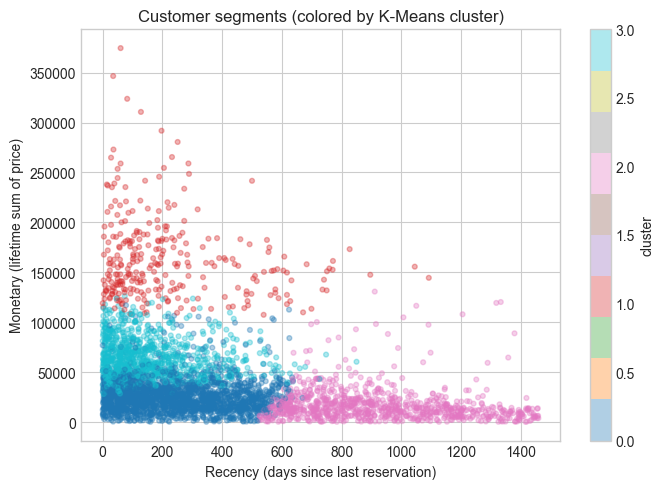

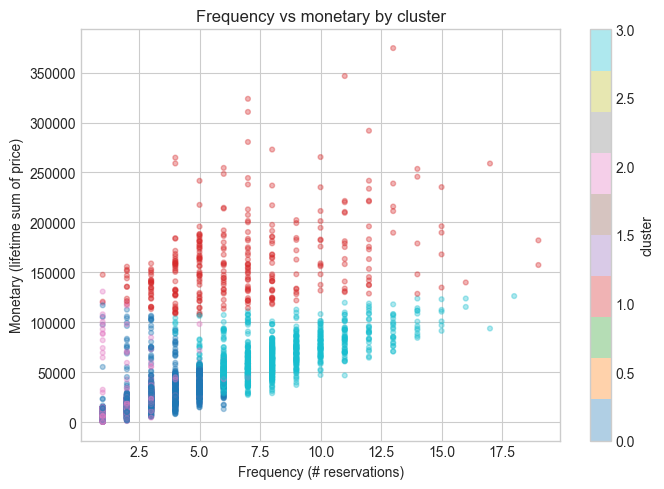

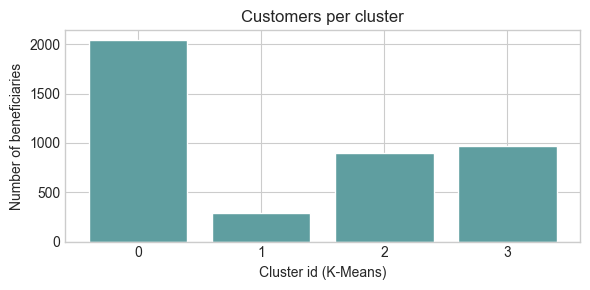

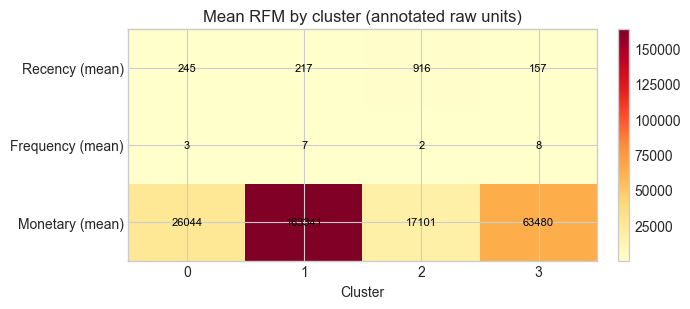

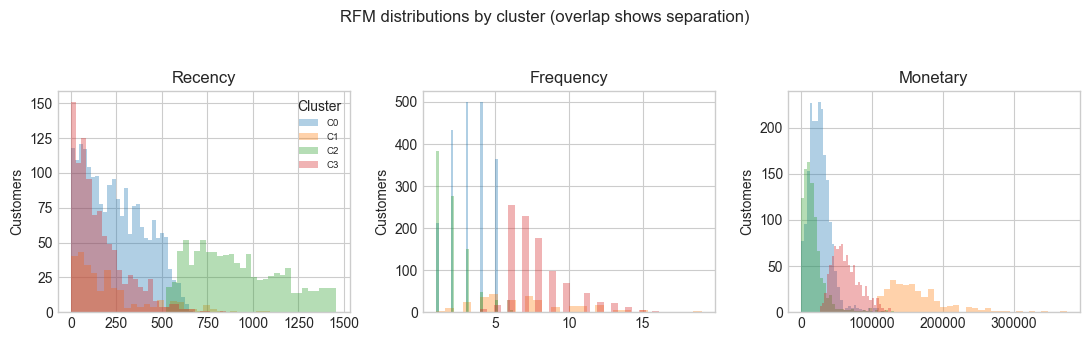

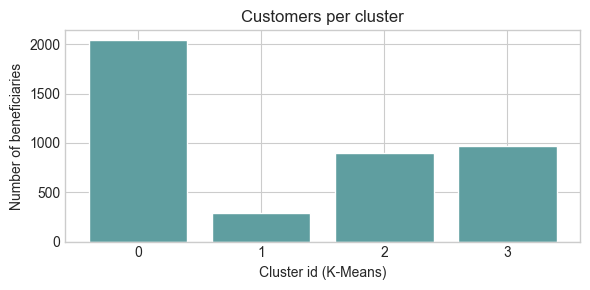

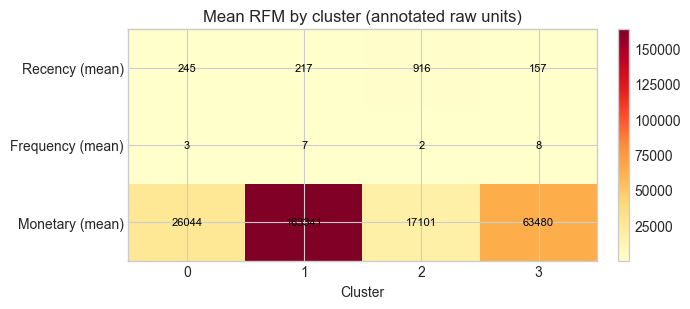

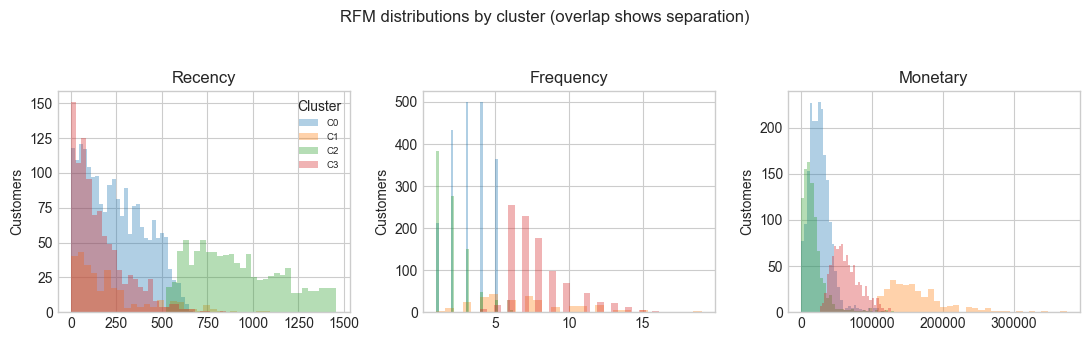

In [11]:
snapshot_date = df_fact["reservation_date"].max().normalize()

rfm = (
    df_fact.groupby("beneficiary_sk")
    .agg(
        recency_days=("reservation_date", lambda s: (snapshot_date - s.max()).days),
        frequency=("id_reservation", "count"),
        monetary=("price", "sum"),
    )
    .reset_index()
)

X = rfm[["recency_days", "frequency", "monetary"]].astype(float)
scaler_seg = StandardScaler()
X_scaled = scaler_seg.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(rfm["recency_days"], rfm["monetary"], c=rfm["cluster"], cmap="tab10", alpha=0.35, s=12)
ax.set_xlabel("Recency (days since last reservation)")
ax.set_ylabel("Monetary (lifetime sum of price)")
ax.set_title("Customer segments (colored by K-Means cluster)")
plt.colorbar(scatter, ax=ax, label="cluster")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(rfm["frequency"], rfm["monetary"], c=rfm["cluster"], cmap="tab10", alpha=0.35, s=12)
ax.set_xlabel("Frequency (# reservations)")
ax.set_ylabel("Monetary (lifetime sum of price)")
ax.set_title("Frequency vs monetary by cluster")
plt.colorbar(scatter, ax=ax, label="cluster")
plt.tight_layout()
plt.show()

# --- Segment sizes & profile heatmap ---
sizes = rfm.groupby("cluster").size().sort_index()
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(sizes.index.astype(str), sizes.values, color="cadetblue", edgecolor="white")
ax.set_xlabel("Cluster id (K-Means)")
ax.set_ylabel("Number of beneficiaries")
ax.set_title("Customers per cluster")
plt.tight_layout()
plt.show()

prof = rfm.groupby("cluster")[["recency_days", "frequency", "monetary"]].mean().sort_index()
Z = prof.values.T  # shape (3 metrics, n clusters) for imshow
fig, ax = plt.subplots(figsize=(7, 3.2))
im = ax.imshow(Z, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(prof.shape[0]))
ax.set_xticklabels([str(c) for c in prof.index])
ax.set_yticks(range(3))
ax.set_yticklabels(["Recency (mean)", "Frequency (mean)", "Monetary (mean)"])
ax.set_xlabel("Cluster")
for j in range(Z.shape[1]):
    for i in range(Z.shape[0]):
        ax.text(j, i, f"{Z[i, j]:.0f}", ha="center", va="center", fontsize=8, color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Mean RFM by cluster (annotated raw units)")
plt.tight_layout()
plt.show()

# Parallel coordinates style: RFM distributions per cluster (overlay)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=False)
for ax, col, title in zip(
    axes,
    ["recency_days", "frequency", "monetary"],
    ["Recency", "Frequency", "Monetary"],
):
    for cl in sorted(rfm["cluster"].unique()):
        subset = rfm.loc[rfm["cluster"] == cl, col]
        ax.hist(subset, bins=30, alpha=0.35, label=f"C{cl}")
    ax.set_title(title)
    ax.set_ylabel("Customers")
axes[0].legend(title="Cluster", fontsize=7, loc="upper right")
plt.suptitle("RFM distributions by cluster (overlap shows separation)", y=1.05)
plt.tight_layout()
plt.show()

# --- Segment sizes & profile heatmap ---
sizes = rfm.groupby("cluster").size().sort_index()
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(sizes.index.astype(str), sizes.values, color="cadetblue", edgecolor="white")
ax.set_xlabel("Cluster id (K-Means)")
ax.set_ylabel("Number of beneficiaries")
ax.set_title("Customers per cluster")
plt.tight_layout()
plt.show()

prof = rfm.groupby("cluster")[["recency_days", "frequency", "monetary"]].mean().sort_index()
Z = prof.values.T  # shape (3 metrics, n clusters) for imshow
fig, ax = plt.subplots(figsize=(7, 3.2))
im = ax.imshow(Z, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(prof.shape[0]))
ax.set_xticklabels([str(c) for c in prof.index])
ax.set_yticks(range(3))
ax.set_yticklabels(["Recency (mean)", "Frequency (mean)", "Monetary (mean)"])
ax.set_xlabel("Cluster")
for j in range(Z.shape[1]):
    for i in range(Z.shape[0]):
        ax.text(j, i, f"{Z[i, j]:.0f}", ha="center", va="center", fontsize=8, color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Mean RFM by cluster (annotated raw units)")
plt.tight_layout()
plt.show()

# Parallel coordinates style: RFM distributions per cluster (overlay)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=False)
for ax, col, title in zip(
    axes,
    ["recency_days", "frequency", "monetary"],
    ["Recency", "Frequency", "Monetary"],
):
    for cl in sorted(rfm["cluster"].unique()):
        subset = rfm.loc[rfm["cluster"] == cl, col]
        ax.hist(subset, bins=30, alpha=0.35, label=f"C{cl}")
    ax.set_title(title)
    ax.set_ylabel("Customers")
axes[0].legend(title="Cluster", fontsize=7, loc="upper right")
plt.suptitle("RFM distributions by cluster (overlap shows separation)", y=1.05)
plt.tight_layout()
plt.show()



## 9. Cluster analysis

We summarize clusters by **mean Recency / Frequency / Monetary**. Marketing labels are assigned **by ordering clusters on business signals** (not by arbitrary cluster id):

1. **High-value customers** — high monetary, relatively low recency, healthy frequency.  
2. **Occasional spenders** — meaningful monetary but intermittent frequency / moderate recency.  
3. **Low-value customers** — low monetary despite activity (or shallow engagement).  
4. **Inactive / at-risk customers** — high recency (long time since last booking), low recent engagement.

Because K-Means labels are arbitrary, we **map cluster ids to these archetypes** using data-driven rules (ranking by monetary and recency).

**Charts above (Section 8):** scatterplots show **geometry** of segments in RFM space. **Bar chart** shows segment **size** (reach of a campaign). **Heatmap** encodes **average RFM** per cluster—darker = higher *relative* value on that axis within this dataset. **Overlaid histograms** show whether clusters are **well separated** or overlapping (overlap implies softer boundaries and more A/B testing before harsh budget cuts).


In [12]:
cluster_profile = (
    rfm.groupby("cluster")[["recency_days", "frequency", "monetary"]].mean().sort_values("monetary", ascending=False)
)
display(cluster_profile)

# Map clusters to interpretable labels using ranks
ordered_by_value = cluster_profile.sort_values(["monetary", "frequency", "recency_days"], ascending=[False, False, True]).index.tolist()
label_cycle = [
    "High-value customers",
    "Occasional spenders",
    "Low-value customers",
    "Inactive / at-risk customers",
]
cluster_to_label = {c: label_cycle[i] for i, c in enumerate(ordered_by_value)}
rfm["segment_label"] = rfm["cluster"].map(cluster_to_label)

summary = rfm.groupby("segment_label", as_index=False)[["recency_days", "frequency", "monetary"]].mean().sort_values(
    "monetary", ascending=False
)
display(summary)

,recency_days,frequency,monetary
cluster,,,
1,217.465517,6.979310,163341.393103
3,157.163561,7.902692,63479.619048
0,244.940167,3.222658,26043.501226
2,915.995531,1.978771,17101.059218


,segment_label,recency_days,frequency,monetary
0,High-value customers,217.465517,6.979310,163341.393103
3,Occasional spenders,157.163561,7.902692,63479.619048
2,Low-value customers,244.940167,3.222658,26043.501226
1,Inactive / at-risk customers,915.995531,1.978771,17101.059218


## 10. Export results

We persist artifacts for dashboards / handoff:
- **`forecast_next_30_days.csv`**
- **`customer_segmentation.csv`** (beneficiary key + RFM + cluster + label)

In [13]:
forecast_path = Path.cwd() / "forecast_next_30_days.csv"
segment_path = Path.cwd() / "customer_segmentation.csv"

forecast_df.to_csv(forecast_path, index=False)
rfm.to_csv(segment_path, index=False)

print("Wrote:", forecast_path.resolve())
print("Wrote:", segment_path.resolve())

Wrote: C:\Users\21658\Desktop\hazem\forecast_next_30_days.csv
Wrote: C:\Users\21658\Desktop\hazem\customer_segmentation.csv


## 11. Business interpretation

### What marketing problems does this surface?
- **High CPA / wasted acquisition spend:** prospecting budgets inflate when demand planning is blind. Misaligned timing (peaks/troughs) creates **overbidding** in digital channels and **discounting** to fill capacity—both raise effective **CPA**.
- **Low retention / churn drag:** beneficiaries with rising **recency** and falling **frequency** are classic churn signals. Without segmentation, retention offers are either **too broad** (margin leak) or **too late** (already disengaged).

### How forecasting improves planning
A credible **30-day reservations outlook** helps marketing and ops coordinate:
- **Budget pacing:** shift spend up when forecasted demand is soft (fill the funnel) and protect margin when demand is strong.
- **Creative & promo calendars:** align campaigns to anticipated weekly seasonality (captured explicitly in **SARIMA**).
- **Capacity & partnerships:** reduce emergency discounts by staffing/partner planning against expected volume.

### How segmentation improves targeting
RFM + clustering turns a giant customer list into **actionable tiers**:
- **High-value customers:** reward, upsell premium services, referral programs (protect **LTV**).
- **Occasional spenders:** nudges tied to relevant event types, bundles, and lifecycle messaging to increase **frequency**.
- **Low-value customers:** test low-cost channels, strict ROI thresholds, educational content before discounting.
- **Inactive / at-risk:** win-back sequences with clear offers, but monitor incremental lift to avoid paying for churn that is already terminal.

**Closing loop:** Re-train models on a schedule (e.g., monthly) as new reservations arrive; refresh segments after material shifts in pricing or product mix.